<a href="https://colab.research.google.com/github/abhishiktadutta/Rainfall-prediction/blob/main/Rainfall_prediction_using_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing the dependencies**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pickle

**Data Collection and Processing**

In [ ]:
#load the dataset to a pandas dataframe
data = pd.read_csv("/content/rainfall.csv")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
data.head()

,date,rainfall,temperature,humidity,wind_speed,weather_condition
0,2022-01-01,12.5,15.2,78.0,8.5,Rainy
1,2022-01-02,8.2,17.8,65.0,5.2,Rainy
2,2022-01-03,0.0,20.1,52.0,3.1,Sunny
3,2022-01-04,3.7,18.6,71.0,6.7,Rainy
4,2022-01-05,21.1,14.8,82.0,9.3,Rainy


In [ ]:
data.tail()

,date,rainfall,temperature,humidity,wind_speed,weather_condition
49,2022-02-19,17.3,15.9,83.0,8.6,Rainy
50,2022-02-20,9.6,18.6,71.0,6.7,Rainy
51,2022-02-21,0.0,21.3,55.0,5.1,Sunny
52,2022-02-22,7.4,16.8,77.0,8.9,Rainy
53,Co,NaN,NaN,NaN,NaN,NaN


In [ ]:
print("Data Info:")
data.info()

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               54 non-null     object 
 1   rainfall           53 non-null     float64
 2   temperature        53 non-null     float64
 3   humidity           53 non-null     float64
 4   wind_speed         53 non-null     float64
 5   weather_condition  53 non-null     object 
dtypes: float64(4), object(2)
memory usage: 2.7+ KB


In [ ]:
data.columns

Index(['date', 'rainfall', 'temperature', 'humidity', 'wind_speed',
       'weather_condition'],
      dtype='object')

In [ ]:
#remove extra spcaes in all columns
data.columns = data.columns.str.strip()

In [ ]:
data.columns

Index(['date', 'rainfall', 'temperature', 'humidity', 'wind_speed',
       'weather_condition'],
      dtype='object')

In [ ]:
print("Data Info:")
data.info()

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               54 non-null     object 
 1   rainfall           53 non-null     float64
 2   temperature        53 non-null     float64
 3   humidity           53 non-null     float64
 4   wind_speed         53 non-null     float64
 5   weather_condition  53 non-null     object 
dtypes: float64(4), object(2)
memory usage: 2.7+ KB


In [ ]:
data = data.drop(columns=['date'])

In [ ]:
#checking the number of missing values
data.isnull().sum()

,0
rainfall,1
temperature,1
humidity,1
wind_speed,1
weather_condition,1


In [ ]:
data["rainfall"].unique()

array([12.5,  8.2,  0. ,  3.7, 21.1, 15.3,  6.8, 11.2, 18.6,  9.5,  2.1,
        7.4, 14.9, 19.2,  5.6, 10.8, 16.3,  3.9,  7.1, 12.7, 18.4,  9.8,
        6.2, 15.5, 21.8, 11.6,  4.3,  9.1, 17.9,  7.5,  5.8, 13.2, 19.6,
       10.4,  6.7, 14.8, 20.5,  8.3,  5.1, 11.9, 17.3,  9.6,  nan])

In [ ]:
data["temperature"].unique()

array([15.2, 17.8, 20.1, 18.6, 14.8, 16.5, 19.2, 21.7, 17.3, 15.8, 16.2,
       19.8, 22.4, 17.9, 15.1, 16.8, 18.5, 21.2, 17.6, 14.5, 16.1, 19.4,
       18.2, 15.7, 17.1, 19.7, 22.9, 14.2, 16.4, 19.1, 21.6, 17.2, 15.4,
       16.7, 18.9, 22.1, 14.7, 19.5, 23.4, 18.1, 13.9, 15.6, 22.7, 17.4,
       14.1, 15.9, 21.3,  nan])

In [ ]:
data["humidity"].unique()

array([78., 65., 52., 71., 82., 75., 61., 48., 73., 79., 72., 58., 45.,
       69., 81., 77., 63., 51., 84., 59., 67., 76., 62., 47., 70., 83.,
       53., 64., 49., 85., 66., 44., 74., 87., 68., 89., 55., nan])

In [ ]:
data["wind_speed"].unique()

array([ 8.5,  5.2,  3.1,  6.7,  9.3,  7.8,  4.5,  2.9,  6.1,  8.9,  5.7,
        3.5,  2.1,  6.5,  8.7,  7.2,  4.9,  3.3,  9.1,  5.3,  4.1,  7.1,
        8.3,  6.8,  4.7,  2.5,  7.3,  9.5,  7.6,  5.1,  3.7,  7.5,  6.2,
        4.3,  2.7,  6.9,  5.5,  7.7,  9.9,  8.2, 10.5,  8.6,  nan])

In [ ]:
data["weather_condition"].unique()

array(['Rainy', 'Sunny', nan], dtype=object)

In [ ]:
#handle missing values
data["rainfall"] = data["rainfall"].fillna(data["rainfall"].mode()[0])
data["temperature"] = data["temperature"].fillna(data["temperature"].median())
data["humidity"] = data["humidity"].fillna(data["humidity"].median())
data["wind_speed"] = data["wind_speed"].fillna(data["wind_speed"].median())
data["weather_condition"] = data["weather_condition"].map({"Rainy": 1, "Sunny": 0})

In [ ]:
#checking the number of missing values
print(data.isnull().sum())

rainfall             0
temperature          0
humidity             0
wind_speed           0
weather_condition    1
dtype: int64


In [ ]:
data.head()

,rainfall,temperature,humidity,wind_speed,weather_condition
0,12.5,15.2,78.0,8.5,1.0
1,8.2,17.8,65.0,5.2,1.0
2,0.0,20.1,52.0,3.1,0.0
3,3.7,18.6,71.0,6.7,1.0
4,21.1,14.8,82.0,9.3,1.0


In [ ]:
data.tail()

,rainfall,temperature,humidity,wind_speed,weather_condition
49,17.3,15.9,83.0,8.6,1.0
50,9.6,18.6,71.0,6.7,1.0
51,0.0,21.3,55.0,5.1,0.0
52,7.4,16.8,77.0,8.9,1.0
53,0.0,17.8,72.0,6.7,NaN


In [ ]:
# fill missing if any
data["weather_condition"] = data["weather_condition"].fillna(0)

In [ ]:
data.head()

,rainfall,temperature,humidity,wind_speed,weather_condition
0,12.5,15.2,78.0,8.5,1.0
1,8.2,17.8,65.0,5.2,1.0
2,0.0,20.1,52.0,3.1,0.0
3,3.7,18.6,71.0,6.7,1.0
4,21.1,14.8,82.0,9.3,1.0


In [ ]:
data.tail()

,rainfall,temperature,humidity,wind_speed,weather_condition
49,17.3,15.9,83.0,8.6,1.0
50,9.6,18.6,71.0,6.7,1.0
51,0.0,21.3,55.0,5.1,0.0
52,7.4,16.8,77.0,8.9,1.0
53,0.0,17.8,72.0,6.7,0.0


In [ ]:
#checking the number of missing values
print(data.isnull().sum())

rainfall             0
temperature          0
humidity             0
wind_speed           0
weather_condition    0
dtype: int64


**EDA**

In [ ]:
#setting plot style for all the plots
sns.set(style="whitegrid")

In [ ]:
data.describe()

,rainfall,temperature,humidity,wind_speed,weather_condition
count,54.000000,54.000000,54.000000,54.000000,54.000000
mean,8.881481,17.948148,69.296296,6.409259,0.777778
std,6.761966,2.477045,11.861830,2.188501,0.419643
min,0.000000,13.900000,44.000000,2.100000,0.000000
25%,3.750000,16.125000,62.250000,4.750000,1.000000
50%,8.250000,17.800000,72.000000,6.700000,1.000000
75%,14.400000,19.350000,78.000000,8.275000,1.000000
max,21.800000,23.400000,89.000000,10.500000,1.000000


In [ ]:
#checking the number of missing values
print(data.isnull().sum())

rainfall             0
temperature          0
humidity             0
wind_speed           0
weather_condition    0
dtype: int64


In [ ]:
data.columns

Index(['rainfall', 'temperature', 'humidity', 'wind_speed',
       'weather_condition'],
      dtype='object')

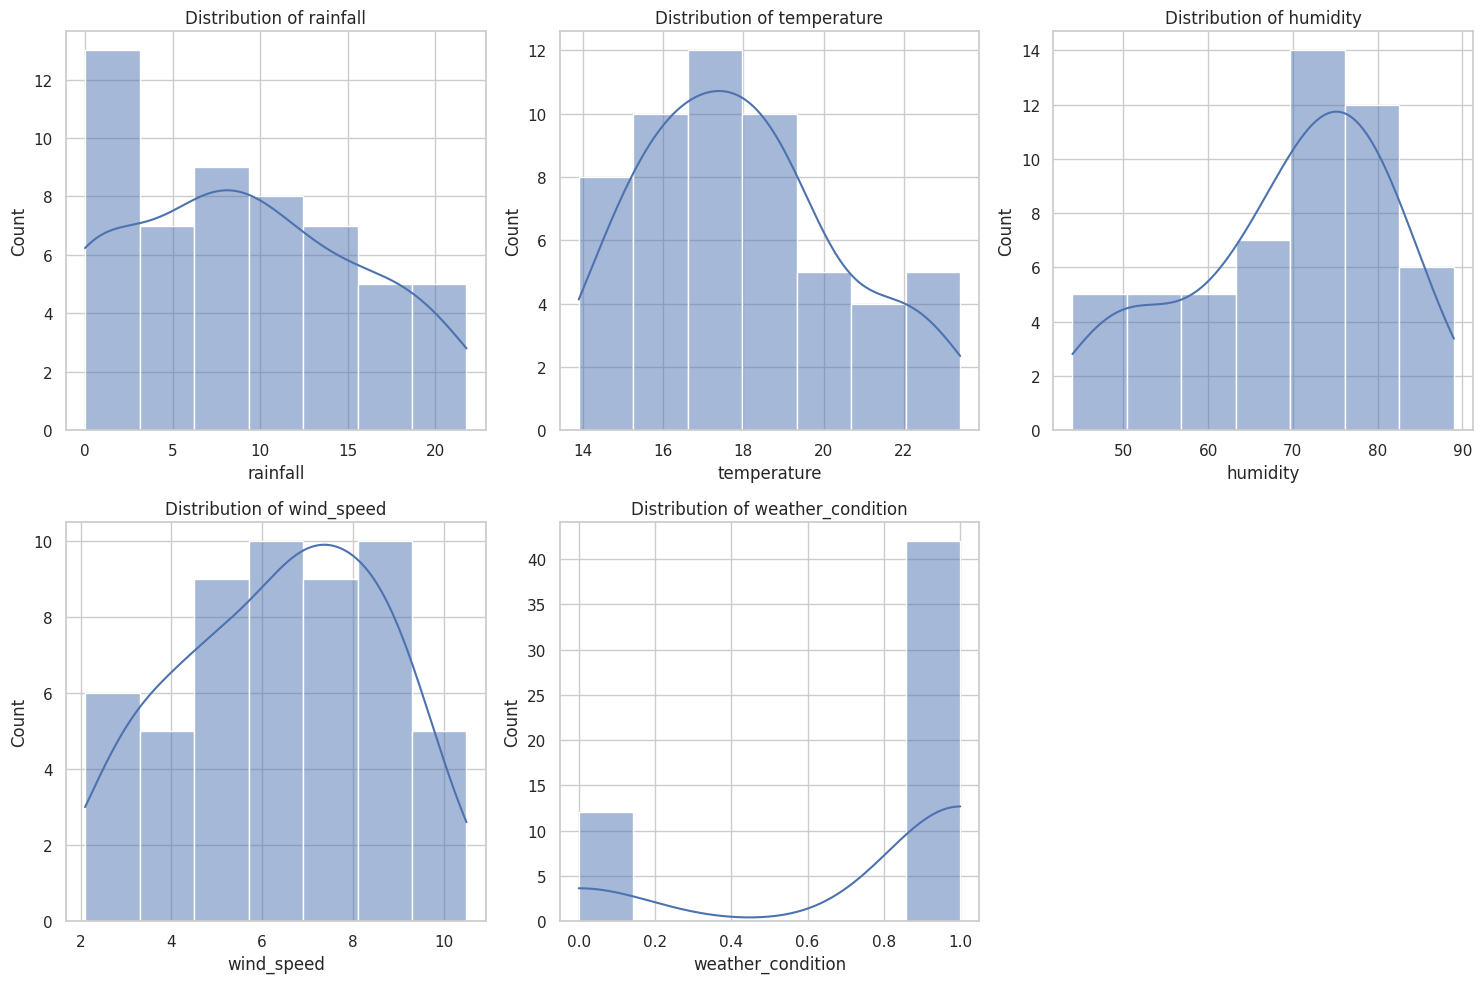

In [ ]:
plt.figure(figsize=(15, 10))

for i, column in enumerate(['rainfall', 'temperature', 'humidity', 'wind_speed', 'weather_condition'], 1):
    plt.subplot(2, 3, i)
    sns.histplot(data[column], kde=True)
    plt.title(f'Distribution of {column}')

plt.tight_layout()
plt.show()

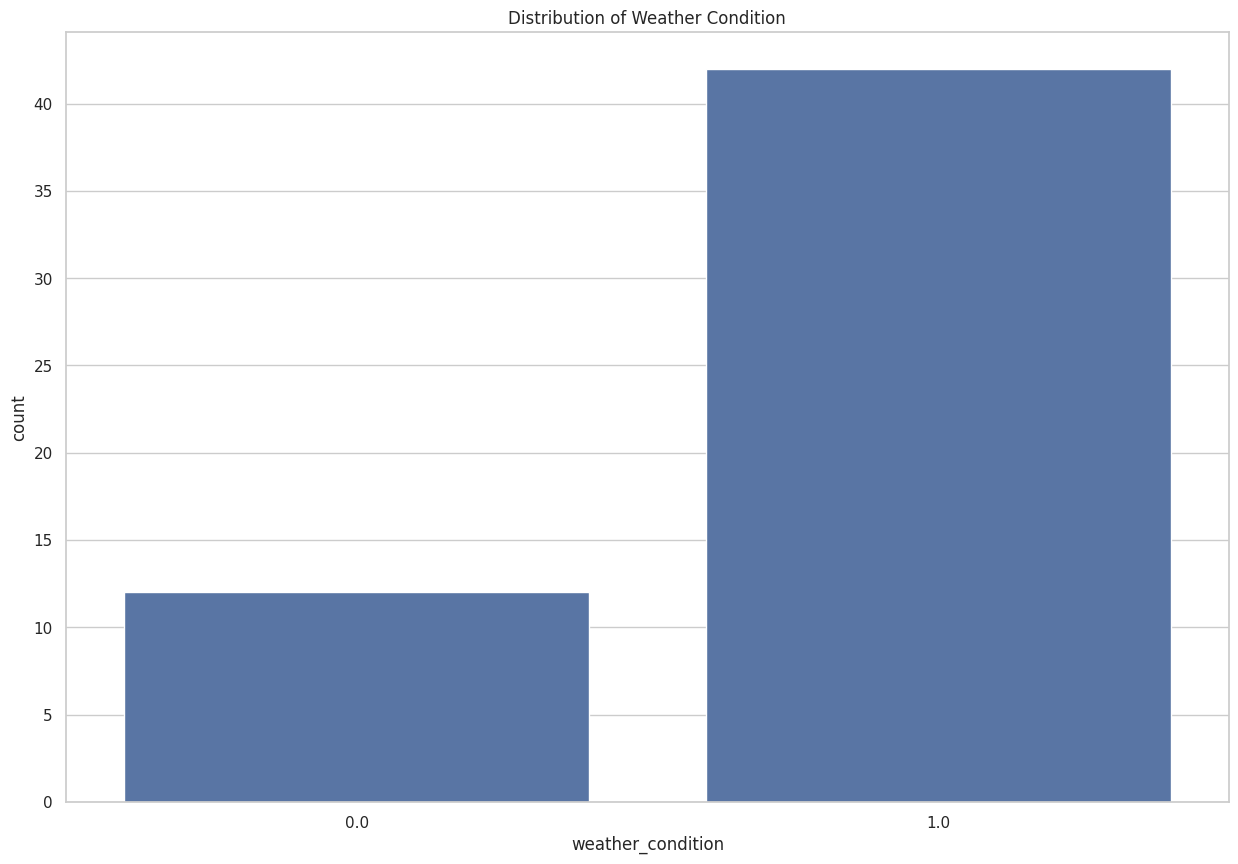

In [ ]:
plt.figure(figsize=(15, 10))
sns.countplot(x='weather_condition', data=data)
plt.title('Distribution of Weather Condition')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

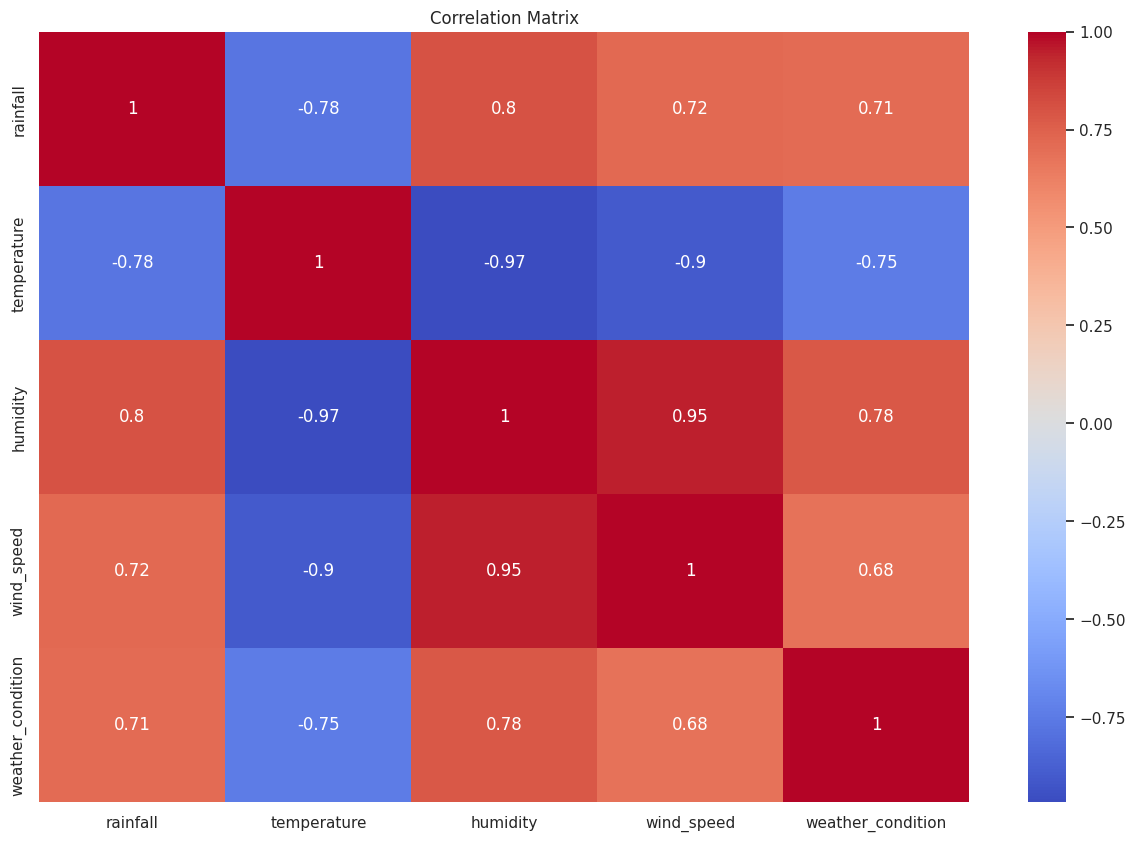

In [ ]:
#correlation matrix
plt.figure(figsize=(15, 10))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm' )
plt.title("Correlation Matrix")
plt.show

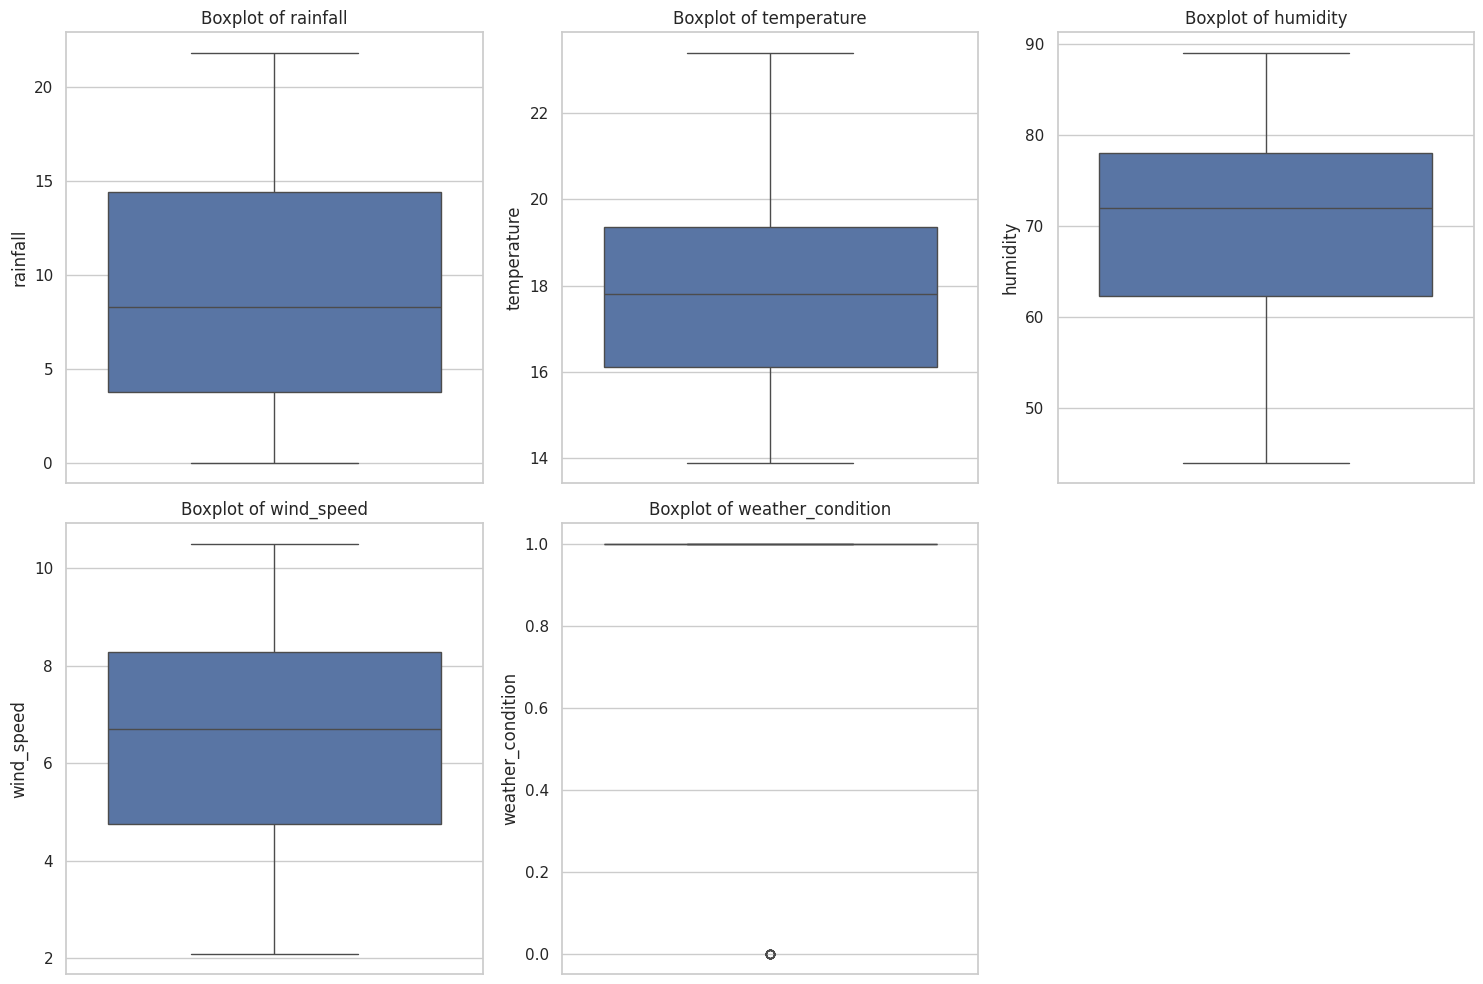

In [ ]:
plt.figure(figsize=(15, 10))

for i, column in enumerate(['rainfall', 'temperature', 'humidity', 'wind_speed', 'weather_condition'], 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data[column])
    plt.title(f'Boxplot of {column}')

plt.tight_layout()
plt.show()

**Data Preprocessing**

In [ ]:
#Drop highly correlated column
data = data.drop(columns=["temperature"])

In [ ]:
data.head()

,rainfall,humidity,wind_speed,weather_condition
0,12.5,78.0,8.5,1.0
1,8.2,65.0,5.2,1.0
2,0.0,52.0,3.1,0.0
3,3.7,71.0,6.7,1.0
4,21.1,82.0,9.3,1.0


In [ ]:
print(data["weather_condition"].value_counts())

weather_condition
1.0    42
0.0    12
Name: count, dtype: int64


In [ ]:
#separate majority and minority class
df_majority = data[data["weather_condition"]== 0]
df_minority = data[data["weather_condition"]== 1]

In [ ]:
print(df_majority.shape)
print(df_minority.shape)

(12, 4)
(42, 4)


In [ ]:
#upsample minority class to match majority count
df_minority_upsampled = resample(df_minority, replace=True, n_samples=len(df_majority), random_state=42)

In [ ]:
df_minority_upsampled.shape

(12, 4)

In [ ]:
df_upsampled = pd.concat([df_majority, df_minority_upsampled])

In [ ]:
#shuffle the final dataframe
df_upsampled = df_upsampled.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
df_upsampled.head()

,rainfall,humidity,wind_speed,weather_condition
0,0.0,44.0,3.1,0.0
1,9.8,62.0,4.7,1.0
2,0.0,52.0,3.1,0.0
3,12.7,79.0,8.3,1.0
4,0.0,72.0,6.7,0.0


In [ ]:
df_upsampled['weather_condition'].value_counts()

,count
weather_condition,
0.0,12
1.0,12


In [ ]:
#splitting the data and target as X and y
X = df_upsampled.drop(columns=["weather_condition"])
y = df_upsampled["weather_condition"]

In [ ]:
print(X)

    rainfall  humidity  wind_speed
0        0.0      44.0         3.1
1        9.8      62.0         4.7
2        0.0      52.0         3.1
3       12.7      79.0         8.3
4        0.0      72.0         6.7
5        0.0      51.0         4.5
6        7.5      64.0         4.3
7        0.0      48.0         2.9
8        7.4      69.0         6.5
9        0.0      47.0         2.5
10       0.0      45.0         2.1
11      11.9      89.0        10.5
12      18.6      79.0         8.9
13       0.0      51.0         3.3
14       0.0      59.0         4.1
15      21.8      78.0         7.6
16      11.9      89.0        10.5
17       7.4      69.0         6.5
18      20.5      81.0         8.2
19       0.0      49.0         2.7
20       0.0      55.0         5.1
21      10.8      75.0         6.7
22      15.5      83.0         9.5
23       0.0      53.0         3.7


In [ ]:
print(y)

0     0.0
1     1.0
2     0.0
3     1.0
4     0.0
5     0.0
6     1.0
7     0.0
8     1.0
9     0.0
10    0.0
11    1.0
12    1.0
13    0.0
14    0.0
15    1.0
16    1.0
17    1.0
18    1.0
19    0.0
20    0.0
21    1.0
22    1.0
23    0.0
Name: weather_condition, dtype: float64


In [ ]:
#splitting the data into training data and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1,2,4]
}

In [ ]:
#hypertuning using GridSearchCV
grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=param_grid_rf, cv=2, n_jobs=-1, verbose=2)
grid_search_rf.fit(X_train, y_train)

Fitting 2 folds for each of 324 candidates, totalling 648 fits


GridSearchCV(cv=2, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': ['sqrt', 'log2', None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             verbose=2)

In [ ]:
best_rf_model = grid_search_rf.best_estimator_

print("best parameters for Random Forest:", grid_search_rf.best_params_)


best parameters for Random Forest: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


**Model Evaluation**

In [ ]:
cv_scores = cross_val_score(best_rf_model, X_train, y_train, cv=2 )
print("Cross-validation scores:", cv_scores)
print("Mean cross-validation score:", cv_scores.mean())

Cross-validation scores: [0.9 1. ]
Mean cross-validation score: 0.95


In [ ]:
#test set performance
y_pred = best_rf_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[1 0]
 [0 4]]
Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         1
         1.0       1.00      1.00      1.00         4

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



**prediction on unknown data**

In [ ]:
input_data = (21.8, 45, 5.5) # Removing temperature and weather_condition

input_df = pd.DataFrame([input_data], columns=['rainfall', 'humidity', 'wind_speed'])


In [ ]:
input_df

,rainfall,humidity,wind_speed
0,21.8,45,5.5


In [ ]:
prediction = best_rf_model.predict(input_df)
print("prediction result:" , "weather_condition" if prediction[0] == 1 else "Not rainy")


prediction result: Not rainy


In [ ]:
#save moedel and features names to a pickle file
model_data = {"model": best_rf_model, "features": list(X.columns)}
with open("rainfall_prediction_model.pkl", "wb") as f:
    pickle.dump(model_data, f)

In [ ]:
import pickle
import pandas as pd


In [ ]:
with open("rainfall_prediction_model.pkl", "rb") as f:
    model_data = pickle.load(f)

In [ ]:
model = model_data["model"]
features = model_data["features"]

In [ ]:
input_data = (21.8, 45, 5.5)
input_df = pd.DataFrame([input_data], columns=features)


In [ ]:
prediction = best_rf_model.predict(input_df)
print("Prediction result:", "weather_condition" if prediction[0] == 1 else "Not Rainy")

Prediction result: Not Rainy
